# Torch and classical random-imagery comparison

## tl;dr

- This notebook compares Logistic Regression, nine classical schema-v3 variants, 12 Torch spectral variants, and canonical non-EEG baselines from immutable artifacts only.
- **No non-reference learned model is promoted as superior to Logistic Regression.** The paired subject-bootstrap tests use the same 2,000 subject-cluster bootstrap draws within each protocol and report Holm-adjusted bootstrap p-values across the 21 non-reference learned models.
- Cross-subject descriptive leaders are classical Ridge Regression and Random Forest, both near 0.518 mean per-pixel balanced accuracy. The top Torch cross-subject estimate is `shallow-convnet-morlet-multilabel` near 0.513.
- Combined bidirectional cross-trial descriptive leaders are Torch STFT variants, led by `deep-convnet-stft-multilabel` near 0.512.
- Score semantics stay visible: Logistic, calibrated SVM/Ridge, and Torch scores are probabilities; classical regressor scores are clipped continuous outputs and are not probabilities.
- Exact 36-pixel reconstruction remains a harsh endpoint; the detailed tables below retain exact match, Hamming loss, IoU, score-MSE, calibration, runtime, parameter counts, and seed diagnostics.

## Context & Methods

All source data are the established `Data_Pattern/patt`, `type="random"` rows with one 36-pixel row-major binary target per full `[0.5, 15.5)` imagery epoch. Cross-subject and identity-overlapping bidirectional cross-trial protocols remain separate.

Every model is loaded through a safe metadata/array reader: `load_evaluation_run` for Logistic Regression, `load_model_run` for schema-v3 classical models, and `load_torch_run` for Torch artifacts. No joblib pipelines and no Torch checkpoint weights are deserialized.

The comparison rejects incompatible artifacts by requiring exact ordered test sample keys, targets, and subject IDs for every model against the Logistic Regression reference. Within-subject results concatenate Trial 1 -> Trial 2 and Trial 2 -> Trial 1 only after confirming the direction sample keys are disjoint.

Uncertainty uses the same 2,000 subject-cluster bootstrap draws for every model within a protocol. Paired balanced-accuracy improvement is model minus Logistic Regression; raw bootstrap p-values are two-sided sign proportions around zero and are Holm-adjusted across the 21 non-reference learned models in each protocol.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-torch-classical-comparison")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from experiments.logistic_regression.artifacts import load_evaluation_run
from experiments.random_imagery.artifacts import load_model_run
from experiments.random_imagery.metrics import evaluate_prediction_matrix
from experiments.random_imagery.registry import (
    PLANNED_MODEL_IDS,
    REFERENCE_MODEL_ID,
    get_model_spec,
)
from experiments.random_imagery_torch.artifacts import load_torch_run
from experiments.random_imagery_torch.config import (
    PRIMARY_TORCH_MODEL_IDS,
    parse_torch_model_id,
)

sns.set_theme(style="whitegrid", context="notebook")

REFERENCE_RUN_DIRS = {
    "cross-subject": (Path("artifacts/experiments/logistic-regression/4fcdf3c4fa5ef75a"),),
    "within-subject": (
        Path("artifacts/experiments/logistic-regression/ea7f8aa10a39cea0"),
        Path("artifacts/experiments/logistic-regression/0ab4cb2a7512ab19"),
    ),
}
CLASSICAL_ROOT = Path("artifacts/experiments/random-imagery")
TORCH_ROOT = Path("artifacts/experiments/random-imagery-torch")
DIRECTION_ORDER = {
    "cross-subject": ("cross-subject",),
    "within-subject": ("trial-1-to-trial-2", "trial-2-to-trial-1"),
}
PROTOCOL_LABELS = {
    "cross-subject": "Cross-subject",
    "within-subject": "Combined bidirectional cross-trial",
}
N_RESAMPLES = 2_000
RANDOM_STATE = 42
CALIBRATION_BINS = 10
METRIC_COLUMNS = (
    "mean_balanced_accuracy",
    "mean_score_mse",
    "mean_sample_iou",
    "micro_iou",
    "hamming_loss",
    "exact_match_accuracy",
)


In [2]:
@dataclass(frozen=True, slots=True)
class CombinedArrays:
    model_id: str
    label: str
    family: str
    task: str
    topology: str
    score_semantics: str
    test_sample_keys: tuple[tuple[int, int, int], ...]
    targets: np.ndarray
    scores: np.ndarray
    predictions: np.ndarray
    subject_ids: np.ndarray
    run_dirs: tuple[Path, ...]
    metadata: dict[str, object]
    baseline_scores: dict[str, np.ndarray] | None = None
    baseline_predictions: dict[str, np.ndarray] | None = None


def _metric_vector(metrics) -> np.ndarray:
    return np.asarray(
        (
            metrics.mean_balanced_accuracy,
            metrics.mean_score_mse,
            metrics.mean_sample_iou,
            metrics.micro_iou,
            metrics.hamming_loss,
            metrics.exact_match_accuracy,
        ),
        dtype=np.float64,
    )


def _order_runs(protocol: str, runs: list[object]) -> list[object]:
    expected = DIRECTION_ORDER[protocol]
    by_direction = {run.evaluation["direction"]["name"]: run for run in runs}
    if len(by_direction) != len(runs) or set(by_direction) != set(expected):
        raise ValueError(f"{protocol} requires directions {expected}; received {tuple(by_direction)}")
    ordered = [by_direction[direction] for direction in expected]
    if any(run.evaluation["protocol"] != protocol for run in ordered):
        raise ValueError("Run protocol differs from requested protocol")
    return ordered


def _combine_runs(
    *,
    model_id: str,
    label: str,
    family: str,
    task: str,
    topology: str,
    score_semantics: str,
    runs: list[object],
    score_attribute: str,
    metadata: dict[str, object],
    baseline_score_attribute: str | None = None,
) -> CombinedArrays:
    keys: list[tuple[int, int, int]] = []
    targets = []
    scores = []
    predictions = []
    subject_ids = []
    run_dirs = []
    baseline_scores: dict[str, list[np.ndarray]] | None = None
    baseline_predictions: dict[str, list[np.ndarray]] | None = None

    for run in runs:
        run_keys = tuple(tuple(key) for key in run.split["test_sample_keys"])
        if set(keys) & set(run_keys):
            raise ValueError(f"{model_id} has overlapping test sample keys across directions")
        keys.extend(run_keys)
        targets.append(run.test_targets)
        scores.append(getattr(run, score_attribute))
        predictions.append(run.predictions)
        subject_ids.append(run.test_subject_ids)
        run_dirs.append(run.run_dir)
        if baseline_score_attribute is not None:
            run_baseline_scores = getattr(run, baseline_score_attribute)
            run_baseline_predictions = run.baseline_predictions
            if baseline_scores is None:
                baseline_scores = {name: [] for name in run_baseline_scores}
                baseline_predictions = {name: [] for name in run_baseline_predictions}
            if baseline_predictions is None or set(run_baseline_scores) != set(baseline_scores):
                raise ValueError("Reference baseline score names differ across directions")
            if set(run_baseline_predictions) != set(baseline_predictions):
                raise ValueError("Reference baseline prediction names differ across directions")
            for name in baseline_scores:
                baseline_scores[name].append(run_baseline_scores[name])
                baseline_predictions[name].append(run_baseline_predictions[name])

    return CombinedArrays(
        model_id=model_id,
        label=label,
        family=family,
        task=task,
        topology=topology,
        score_semantics=score_semantics,
        test_sample_keys=tuple(keys),
        targets=np.asarray(np.concatenate(targets, axis=0), dtype=np.int8),
        scores=np.asarray(np.concatenate(scores, axis=0), dtype=np.float64),
        predictions=np.asarray(np.concatenate(predictions, axis=0), dtype=np.int8),
        subject_ids=np.asarray(np.concatenate(subject_ids), dtype=np.int64),
        run_dirs=tuple(run_dirs),
        metadata=metadata,
        baseline_scores=None
        if baseline_scores is None
        else {name: np.concatenate(parts, axis=0) for name, parts in baseline_scores.items()},
        baseline_predictions=None
        if baseline_predictions is None
        else {name: np.concatenate(parts, axis=0) for name, parts in baseline_predictions.items()},
    )


def _bootstrap_rows(targets: np.ndarray, subject_ids: np.ndarray) -> tuple[list[np.ndarray], int]:
    unique_subjects = np.unique(subject_ids)
    subject_rows = {int(subject): np.flatnonzero(subject_ids == subject) for subject in unique_subjects}
    rng = np.random.default_rng(RANDOM_STATE)
    rows: list[np.ndarray] = []
    attempts = 0
    max_attempts = N_RESAMPLES * 100
    while len(rows) < N_RESAMPLES and attempts < max_attempts:
        attempts += 1
        drawn = rng.choice(unique_subjects, size=unique_subjects.size, replace=True)
        indices = np.concatenate([subject_rows[int(subject)] for subject in drawn])
        sampled_targets = targets[indices]
        positives = sampled_targets.sum(axis=0, dtype=np.int64)
        if np.any(positives == 0) or np.any(positives == sampled_targets.shape[0]):
            continue
        rows.append(indices.astype(np.int64))
    if len(rows) != N_RESAMPLES:
        raise RuntimeError("Could not draw enough class-complete subject bootstrap samples")
    return rows, attempts


def _bootstrap_metric_matrix(arrays: CombinedArrays, rows: list[np.ndarray]) -> np.ndarray:
    values = np.empty((len(rows), len(METRIC_COLUMNS)), dtype=np.float64)
    for index, row_indices in enumerate(rows):
        values[index] = _metric_vector(
            evaluate_prediction_matrix(
                arrays.targets[row_indices],
                arrays.predictions[row_indices],
                arrays.scores[row_indices],
            )
        )
    return values


def _calibration_ece(targets: np.ndarray, scores: np.ndarray, bins: int = CALIBRATION_BINS) -> float:
    flat_targets = targets.reshape(-1)
    flat_scores = scores.reshape(-1)
    edges = np.linspace(0.0, 1.0, bins + 1)
    assignments = np.minimum(np.searchsorted(edges, flat_scores, side="right") - 1, bins - 1)
    assignments = np.maximum(assignments, 0)
    weighted_error = 0.0
    for bin_index in range(bins):
        mask = assignments == bin_index
        count = int(mask.sum())
        if count == 0:
            continue
        weighted_error += count * abs(float(flat_scores[mask].mean()) - float(flat_targets[mask].mean()))
    return float(weighted_error / flat_scores.size)


def _holm_adjust(p_values: np.ndarray) -> np.ndarray:
    order = np.argsort(p_values)
    adjusted = np.empty_like(p_values, dtype=np.float64)
    running = 0.0
    m = p_values.size
    for rank, original_index in enumerate(order):
        value = (m - rank) * float(p_values[original_index])
        running = max(running, value)
        adjusted[original_index] = min(1.0, running)
    return adjusted


def _torch_label(model_id: str) -> str:
    architecture, method = parse_torch_model_id(model_id)
    architecture_label = {
        "eegnet": "EEGNet",
        "deep-convnet": "DeepConvNet",
        "shallow-convnet": "ShallowConvNet",
    }[architecture]
    return f"{architecture_label} / {method.upper()}"


In [3]:
def load_reference(protocol: str) -> CombinedArrays:
    runs = _order_runs(protocol, [load_evaluation_run(path) for path in REFERENCE_RUN_DIRS[protocol]])
    spec = get_model_spec(REFERENCE_MODEL_ID)
    selected = tuple(tuple(run.evaluation["selected_feature_family"]) for run in runs)
    return _combine_runs(
        model_id=REFERENCE_MODEL_ID,
        label=spec.label,
        family="Reference",
        task=spec.task,
        topology=spec.topology,
        score_semantics=spec.score_semantics,
        runs=runs,
        score_attribute="probabilities",
        baseline_score_attribute="baseline_probabilities",
        metadata={"features": selected, "parameter_count": np.nan, "training_seconds": np.nan},
    )


def load_classical(protocol: str, model_id: str) -> CombinedArrays:
    runs = []
    for run_dir in sorted((CLASSICAL_ROOT / model_id).iterdir()):
        run = load_model_run(run_dir)
        if run.evaluation["protocol"] == protocol:
            runs.append(run)
    ordered = _order_runs(protocol, runs)
    spec = get_model_spec(model_id)
    selected = tuple(tuple(run.evaluation["selected_feature_family"]) for run in ordered)
    diagnostics = [run.results.get("score_diagnostics", {}) for run in ordered]
    weights = [int(run.predictions.size) for run in ordered]
    below = [float(item.get("clipped_below_zero_fraction", np.nan)) for item in diagnostics]
    above = [float(item.get("clipped_above_one_fraction", np.nan)) for item in diagnostics]
    return _combine_runs(
        model_id=model_id,
        label=spec.label,
        family="Classical",
        task=spec.task,
        topology=spec.topology,
        score_semantics=spec.score_semantics,
        runs=ordered,
        score_attribute="scores",
        metadata={
            "features": selected,
            "pipeline_count": tuple(int(run.results["pipeline_count"]) for run in ordered),
            "clipped_below_zero_fraction": np.nan
            if np.isnan(below).all()
            else float(np.average(below, weights=weights)),
            "clipped_above_one_fraction": np.nan
            if np.isnan(above).all()
            else float(np.average(above, weights=weights)),
            "parameter_count": np.nan,
            "training_seconds": np.nan,
        },
    )


def load_torch(protocol: str, model_id: str) -> CombinedArrays:
    runs = []
    for run_dir in sorted((TORCH_ROOT / model_id).iterdir()):
        run = load_torch_run(run_dir)
        if run.evaluation["protocol"] == protocol:
            runs.append(run)
    ordered = _order_runs(protocol, runs)
    architecture, method = parse_torch_model_id(model_id)
    member_ba = []
    for run in ordered:
        per_run = []
        for seed_scores in run.member_scores:
            seed_predictions = (seed_scores >= run.config.training.prediction_threshold).astype(np.int8)
            per_run.append(
                evaluate_prediction_matrix(run.test_targets, seed_predictions, seed_scores).mean_balanced_accuracy
            )
        member_ba.extend(per_run)
    return _combine_runs(
        model_id=model_id,
        label=_torch_label(model_id),
        family="Torch",
        task="classifier",
        topology="multilabel",
        score_semantics="native_probability",
        runs=ordered,
        score_attribute="scores",
        metadata={
            "architecture": architecture,
            "method": method,
            "parameter_count": int(ordered[0].training["parameter_count"]),
            "selected_epoch_count": tuple(int(run.training["selected_epoch_count"]) for run in ordered),
            "training_seconds": float(sum(run.training["training_seconds"] for run in ordered)),
            "prediction_seconds": float(sum(run.training["prediction_seconds"] for run in ordered)),
            "seed_ba_min": float(np.min(member_ba)),
            "seed_ba_max": float(np.max(member_ba)),
            "seed_ba_std": float(np.std(member_ba)),
        },
    )


def load_protocol_arrays(protocol: str) -> list[CombinedArrays]:
    reference = load_reference(protocol)
    arrays = [reference]
    arrays.extend(load_classical(protocol, model_id) for model_id in PLANNED_MODEL_IDS)
    arrays.extend(load_torch(protocol, model_id) for model_id in PRIMARY_TORCH_MODEL_IDS)
    for candidate in arrays[1:]:
        if candidate.test_sample_keys != reference.test_sample_keys:
            raise ValueError(f"{candidate.model_id} uses different ordered test sample keys")
        if not np.array_equal(candidate.targets, reference.targets):
            raise ValueError(f"{candidate.model_id} uses different test targets")
        if not np.array_equal(candidate.subject_ids, reference.subject_ids):
            raise ValueError(f"{candidate.model_id} uses different test subjects")
    return arrays


protocol_arrays = {protocol: load_protocol_arrays(protocol) for protocol in DIRECTION_ORDER}
assert {len(items) for items in protocol_arrays.values()} == {22}
assert all(items[0].model_id == REFERENCE_MODEL_ID for items in protocol_arrays.values())
protocol_context = {
    protocol: {
        "test_rows": int(items[0].targets.shape[0]),
        "subjects": int(np.unique(items[0].subject_ids).size),
        "learned_models": len(items),
        "non_reference_learned_models": len(items) - 1,
    }
    for protocol, items in protocol_arrays.items()
}
protocol_context


{'cross-subject': {'test_rows': 39,
  'subjects': 7,
  'learned_models': 22,
  'non_reference_learned_models': 21},
 'within-subject': {'test_rows': 162,
  'subjects': 27,
  'learned_models': 22,
  'non_reference_learned_models': 21}}

## Protocol Tables

These tables are descriptive protocol-specific summaries. `score_mse` is Brier score for probability models and clipped MSE for regressors, so score semantics are retained in every row.

In [4]:
comparison_rows = []
contrast_rows = []
baseline_rows = []
calibration_rows = []
runtime_rows = []
bootstrap_attempts = {}

for protocol, arrays_list in protocol_arrays.items():
    reference = arrays_list[0]
    rows, attempts = _bootstrap_rows(reference.targets, reference.subject_ids)
    bootstrap_attempts[protocol] = attempts
    reference_samples = _bootstrap_metric_matrix(reference, rows)
    reference_metrics = evaluate_prediction_matrix(reference.targets, reference.predictions, reference.scores)
    reference_values = _metric_vector(reference_metrics)
    raw_p_values = []
    raw_p_indices = []

    for arrays in arrays_list:
        metrics = evaluate_prediction_matrix(arrays.targets, arrays.predictions, arrays.scores)
        values = _metric_vector(metrics)
        samples = _bootstrap_metric_matrix(arrays, rows)
        ba_low, ba_high = np.quantile(samples[:, 0], (0.025, 0.975), method="linear")
        comparison_rows.append(
            {
                "protocol": protocol,
                "protocol_label": PROTOCOL_LABELS[protocol],
                "model_id": arrays.model_id,
                "model": arrays.label,
                "family": arrays.family,
                "task": arrays.task,
                "topology": arrays.topology,
                "score_semantics": arrays.score_semantics,
                "n_test_rows": int(arrays.targets.shape[0]),
                "n_subjects": int(np.unique(arrays.subject_ids).size),
                "balanced_accuracy": values[0],
                "ba_ci_low": float(ba_low),
                "ba_ci_high": float(ba_high),
                "score_mse": values[1],
                "sample_iou": values[2],
                "micro_iou": values[3],
                "hamming_loss": values[4],
                "exact_match": values[5],
            }
        )
        runtime_rows.append(
            {
                "protocol": protocol,
                "model_id": arrays.model_id,
                "model": arrays.label,
                "family": arrays.family,
                "parameter_count": arrays.metadata.get("parameter_count", np.nan),
                "training_seconds": arrays.metadata.get("training_seconds", np.nan),
                "prediction_seconds": arrays.metadata.get("prediction_seconds", np.nan),
                "seed_ba_min": arrays.metadata.get("seed_ba_min", np.nan),
                "seed_ba_max": arrays.metadata.get("seed_ba_max", np.nan),
                "seed_ba_std": arrays.metadata.get("seed_ba_std", np.nan),
            }
        )
        if arrays.score_semantics in {"native_probability", "calibrated_probability"}:
            calibration_rows.append(
                {
                    "protocol": protocol,
                    "model_id": arrays.model_id,
                    "model": arrays.label,
                    "family": arrays.family,
                    "score_semantics": arrays.score_semantics,
                    "ece": _calibration_ece(arrays.targets, arrays.scores),
                }
            )
        if arrays.model_id == REFERENCE_MODEL_ID:
            continue
        ba_improvement_samples = samples[:, 0] - reference_samples[:, 0]
        raw_p = min(
            1.0,
            2.0 * min(float(np.mean(ba_improvement_samples <= 0.0)), float(np.mean(ba_improvement_samples >= 0.0))),
        )
        raw_p_indices.append(len(contrast_rows))
        raw_p_values.append(raw_p)
        for metric_index, metric in enumerate(METRIC_COLUMNS):
            sign = -1.0 if metric in {"mean_score_mse", "hamming_loss"} else 1.0
            improvement_samples = sign * (samples[:, metric_index] - reference_samples[:, metric_index])
            low, high = np.quantile(improvement_samples, (0.025, 0.975), method="linear")
            contrast_rows.append(
                {
                    "protocol": protocol,
                    "model_id": arrays.model_id,
                    "model": arrays.label,
                    "family": arrays.family,
                    "metric": metric,
                    "model_estimate": values[metric_index],
                    "reference_estimate": reference_values[metric_index],
                    "improvement": sign * (values[metric_index] - reference_values[metric_index]),
                    "pointwise_low": float(low),
                    "pointwise_high": float(high),
                    "raw_bootstrap_p": raw_p if metric == "mean_balanced_accuracy" else np.nan,
                    "holm_p": np.nan,
                }
            )
    adjusted = _holm_adjust(np.asarray(raw_p_values, dtype=np.float64))
    for row_index, adjusted_p in zip(raw_p_indices, adjusted, strict=True):
        contrast_rows[row_index]["holm_p"] = float(adjusted_p)

    if reference.baseline_scores is not None and reference.baseline_predictions is not None:
        for name, scores in reference.baseline_scores.items():
            metrics = evaluate_prediction_matrix(reference.targets, reference.baseline_predictions[name], scores)
            baseline_rows.append(
                {
                    "protocol": protocol,
                    "baseline": name,
                    "balanced_accuracy": metrics.mean_balanced_accuracy,
                    "score_mse": metrics.mean_score_mse,
                    "sample_iou": metrics.mean_sample_iou,
                    "hamming_loss": metrics.hamming_loss,
                    "exact_match": metrics.exact_match_accuracy,
                }
            )

comparison_df = pd.DataFrame(comparison_rows)
contrast_df = pd.DataFrame(contrast_rows)
baseline_df = pd.DataFrame(baseline_rows)
calibration_df = pd.DataFrame(calibration_rows)
runtime_df = pd.DataFrame(runtime_rows)

assert comparison_df.shape[0] == 44
assert contrast_df[contrast_df["metric"] == "mean_balanced_accuracy"].shape[0] == 42
assert set(comparison_df["protocol"]) == {"cross-subject", "within-subject"}
assert comparison_df.groupby("protocol")["model_id"].nunique().eq(22).all()
assert comparison_df["exact_match"].eq(0.0).all()
assert contrast_df.loc[contrast_df["metric"] == "mean_balanced_accuracy", "holm_p"].notna().all()
pd.DataFrame(
    [
        {"protocol": protocol, **context, "bootstrap_attempts": bootstrap_attempts[protocol]}
        for protocol, context in protocol_context.items()
    ]
)


,protocol,test_rows,subjects,learned_models,non_reference_learned_models,bootstrap_attempts
0,cross-subject,39,7,22,21,2002
1,within-subject,162,27,22,21,2000


In [5]:
for protocol in DIRECTION_ORDER:
    print(PROTOCOL_LABELS[protocol])
    display(
        comparison_df[comparison_df["protocol"] == protocol]
        .sort_values("balanced_accuracy", ascending=False)
        [[
            "family",
            "model",
            "score_semantics",
            "balanced_accuracy",
            "ba_ci_low",
            "ba_ci_high",
            "score_mse",
            "sample_iou",
            "hamming_loss",
            "exact_match",
        ]]
        .style.format(
            {
                "balanced_accuracy": "{:.6f}",
                "ba_ci_low": "{:.6f}",
                "ba_ci_high": "{:.6f}",
                "score_mse": "{:.6f}",
                "sample_iou": "{:.6f}",
                "hamming_loss": "{:.6f}",
                "exact_match": "{:.6f}",
            }
        )
    )


Cross-subject


,family,model,score_semantics,balanced_accuracy,ba_ci_low,ba_ci_high,score_mse,sample_iou,hamming_loss,exact_match
3,Classical,Ridge Regression (independent),clipped_regression,0.518382,0.486733,0.561786,0.332469,0.326754,0.481481,0.000000
7,Classical,Random Forest Regressor (independent),clipped_regression,0.518206,0.502674,0.530584,0.264733,0.328908,0.475783,0.000000
19,Torch,ShallowConvNet / MORLET,native_probability,0.513443,0.488845,0.536044,0.251392,0.331591,0.475071,0.000000
5,Classical,ElasticNet/Lasso (independent),clipped_regression,0.512399,0.490833,0.531357,0.301434,0.325165,0.482906,0.000000
0,Reference,Logistic Regression,native_probability,0.509991,0.496384,0.521077,0.333967,0.335258,0.485755,0.000000
17,Torch,DeepConvNet / STFT,native_probability,0.509145,0.491834,0.525755,0.257238,0.355689,0.482906,0.000000
15,Torch,DeepConvNet / MORLET,native_probability,0.508782,0.483808,0.538586,0.250729,0.355969,0.486467,0.000000
10,Torch,EEGNet / FFT,native_probability,0.508186,0.480997,0.538359,0.249993,0.352046,0.496439,0.000000
6,Classical,ElasticNet/Lasso (multi-output),clipped_regression,0.506086,0.478602,0.528878,0.339250,0.336574,0.485755,0.000000
18,Torch,ShallowConvNet / FFT,native_probability,0.505675,0.471549,0.534897,0.251356,0.349155,0.490028,0.000000


Combined bidirectional cross-trial


,family,model,score_semantics,balanced_accuracy,ba_ci_low,ba_ci_high,score_mse,sample_iou,hamming_loss,exact_match
39,Torch,DeepConvNet / STFT,native_probability,0.512011,0.500668,0.520872,0.262771,0.343311,0.485254,0.000000
35,Torch,EEGNet / STFT,native_probability,0.510924,0.498673,0.520471,0.251851,0.332547,0.487826,0.000000
38,Torch,DeepConvNet / SUPERLET,native_probability,0.506225,0.491947,0.517677,0.253675,0.348788,0.492627,0.000000
28,Classical,ElasticNet/Lasso (multi-output),clipped_regression,0.503457,0.490003,0.516148,0.360940,0.324927,0.493141,0.000000
36,Torch,DeepConvNet / FFT,native_probability,0.502737,0.490701,0.513439,0.264091,0.347610,0.494684,0.000000
37,Torch,DeepConvNet / MORLET,native_probability,0.500067,0.487988,0.509487,0.279770,0.332683,0.496914,0.000000
22,Reference,Logistic Regression,native_probability,0.500014,0.486067,0.511483,0.363552,0.335853,0.496399,0.000000
29,Classical,Random Forest Regressor (independent),clipped_regression,0.499495,0.485711,0.510605,0.284041,0.324892,0.493656,0.000000
42,Torch,ShallowConvNet / SUPERLET,native_probability,0.499370,0.485162,0.510761,0.253585,0.332876,0.497428,0.000000
32,Torch,EEGNet / FFT,native_probability,0.499251,0.488162,0.508790,0.250747,0.336466,0.500686,0.000000


## Multiplicity-Aware Contrasts

The primary contrast is paired mean per-pixel balanced-accuracy improvement over Logistic Regression. Intervals are pointwise bootstrap intervals; Holm-adjusted bootstrap p-values are corrected across the 21 non-reference learned models within each protocol.

In [6]:
ba_contrasts = contrast_df[contrast_df["metric"] == "mean_balanced_accuracy"].copy()
for protocol in DIRECTION_ORDER:
    print(PROTOCOL_LABELS[protocol])
    display(
        ba_contrasts[ba_contrasts["protocol"] == protocol]
        .sort_values("improvement", ascending=False)
        [["family", "model", "model_estimate", "reference_estimate", "improvement", "pointwise_low", "pointwise_high", "raw_bootstrap_p", "holm_p"]]
        .style.format(
            {
                "model_estimate": "{:.6f}",
                "reference_estimate": "{:.6f}",
                "improvement": "{:+.6f}",
                "pointwise_low": "{:+.6f}",
                "pointwise_high": "{:+.6f}",
                "raw_bootstrap_p": "{:.4f}",
                "holm_p": "{:.4f}",
            }
        )
    )

assert (ba_contrasts["holm_p"] >= ba_contrasts["raw_bootstrap_p"]).all()
assert not (ba_contrasts["holm_p"] < 0.05).any()


Cross-subject


,family,model,model_estimate,reference_estimate,improvement,pointwise_low,pointwise_high,raw_bootstrap_p,holm_p
12,Classical,Ridge Regression (independent),0.518382,0.509991,+0.008391,-0.024562,+0.060293,0.6210,1.0000
36,Classical,Random Forest Regressor (independent),0.518206,0.509991,+0.008215,-0.011754,+0.026133,0.3680,1.0000
108,Torch,ShallowConvNet / MORLET,0.513443,0.509991,+0.003452,-0.017862,+0.026112,0.7860,1.0000
24,Classical,ElasticNet/Lasso (independent),0.512399,0.509991,+0.002408,-0.019377,+0.017127,0.8410,1.0000
96,Torch,DeepConvNet / STFT,0.509145,0.509991,-0.000846,-0.018513,+0.014407,0.9620,1.0000
84,Torch,DeepConvNet / MORLET,0.508782,0.509991,-0.001209,-0.026983,+0.025397,0.9430,1.0000
54,Torch,EEGNet / FFT,0.508186,0.509991,-0.001805,-0.035305,+0.038593,0.9470,1.0000
30,Classical,ElasticNet/Lasso (multi-output),0.506086,0.509991,-0.003905,-0.038090,+0.027203,0.9230,1.0000
102,Torch,ShallowConvNet / FFT,0.505675,0.509991,-0.004316,-0.041993,+0.033897,0.8580,1.0000
42,Classical,Random Forest Regressor (multi-output),0.504499,0.509991,-0.005492,-0.030890,+0.022336,0.7010,1.0000


Combined bidirectional cross-trial


,family,model,model_estimate,reference_estimate,improvement,pointwise_low,pointwise_high,raw_bootstrap_p,holm_p
222,Torch,DeepConvNet / STFT,0.512011,0.500014,+0.011997,-0.000822,+0.024570,0.0680,1.0000
198,Torch,EEGNet / STFT,0.510924,0.500014,+0.010910,-0.003413,+0.025937,0.1440,1.0000
216,Torch,DeepConvNet / SUPERLET,0.506225,0.500014,+0.006211,-0.008370,+0.020668,0.4290,1.0000
156,Classical,ElasticNet/Lasso (multi-output),0.503457,0.500014,+0.003443,-0.014363,+0.021730,0.6630,1.0000
204,Torch,DeepConvNet / FFT,0.502737,0.500014,+0.002724,-0.011190,+0.015901,0.6820,1.0000
210,Torch,DeepConvNet / MORLET,0.500067,0.500014,+0.000054,-0.013981,+0.014129,0.9910,1.0000
162,Classical,Random Forest Regressor (independent),0.499495,0.500014,-0.000519,-0.015449,+0.013874,0.8930,1.0000
240,Torch,ShallowConvNet / SUPERLET,0.499370,0.500014,-0.000644,-0.013257,+0.012297,0.8880,1.0000
180,Torch,EEGNet / FFT,0.499251,0.500014,-0.000763,-0.016251,+0.015077,0.9720,1.0000
192,Torch,EEGNet / SUPERLET,0.499157,0.500014,-0.000857,-0.021247,+0.020553,0.9670,1.0000


## Calibration And Score Semantics

Calibration is shown only for probability scores. Classical regressors expose clipped continuous scores; those are not probabilities and are excluded from ECE.

In [7]:
display(
    calibration_df.sort_values(["protocol", "ece"])
    .reset_index(drop=True)
    .style.format({"ece": "{:.6f}"})
)

display(
    baseline_df.sort_values(["protocol", "score_mse"])
    .reset_index(drop=True)
    .style.format(
        {
            "balanced_accuracy": "{:.6f}",
            "score_mse": "{:.6f}",
            "sample_iou": "{:.6f}",
            "hamming_loss": "{:.6f}",
            "exact_match": "{:.6f}",
        }
    )
)


,protocol,model_id,model,family,score_semantics,ece
0,cross-subject,eegnet-superlet-multilabel,EEGNet / SUPERLET,Torch,native_probability,0.020500
1,cross-subject,eegnet-stft-multilabel,EEGNet / STFT,Torch,native_probability,0.020927
2,cross-subject,eegnet-morlet-multilabel,EEGNet / MORLET,Torch,native_probability,0.021248
3,cross-subject,eegnet-fft-multilabel,EEGNet / FFT,Torch,native_probability,0.021618
4,cross-subject,shallow-convnet-morlet-multilabel,ShallowConvNet / MORLET,Torch,native_probability,0.023767
5,cross-subject,deep-convnet-morlet-multilabel,DeepConvNet / MORLET,Torch,native_probability,0.026735
6,cross-subject,shallow-convnet-stft-multilabel,ShallowConvNet / STFT,Torch,native_probability,0.029268
7,cross-subject,shallow-convnet-fft-multilabel,ShallowConvNet / FFT,Torch,native_probability,0.030970
8,cross-subject,ridge-classifier-independent,Ridge Classifier,Classical,calibrated_probability,0.032203
9,cross-subject,shallow-convnet-superlet-multilabel,ShallowConvNet / SUPERLET,Torch,native_probability,0.037762


,protocol,baseline,balanced_accuracy,score_mse,sample_iou,hamming_loss,exact_match
0,cross-subject,global_majority,0.500000,0.249715,0.000000,0.478632,0.000000
1,cross-subject,pixel_frequency,0.500000,0.250529,0.293694,0.475783,0.000000
2,cross-subject,seeded_bernoulli,0.500395,0.250529,0.326009,0.497151,0.000000
3,within-subject,global_majority,0.500000,0.250100,0.000000,0.487826,0.000000
4,within-subject,pixel_frequency,0.474200,0.254606,0.281746,0.501715,0.000000
5,within-subject,seeded_bernoulli,0.502447,0.254606,0.328012,0.494684,0.000000


## Runtime, Parameters, And Seeds

Torch artifacts persist training/prediction seconds, trainable parameter count, and three-seed member diagnostics. Classical schema-v3 artifacts persist pipeline counts but not comparable wall-clock runtime or trainable-parameter counts, so those cells remain missing rather than estimated from notebook logs.

In [8]:
display(
    runtime_df[runtime_df["family"] == "Torch"]
    .sort_values(["protocol", "training_seconds"], ascending=[True, False])
    .reset_index(drop=True)
    .style.format(
        {
            "parameter_count": "{:.0f}",
            "training_seconds": "{:.2f}",
            "prediction_seconds": "{:.4f}",
            "seed_ba_min": "{:.6f}",
            "seed_ba_max": "{:.6f}",
            "seed_ba_std": "{:.6f}",
        }
    )
)


,protocol,model_id,model,family,parameter_count,training_seconds,prediction_seconds,seed_ba_min,seed_ba_max,seed_ba_std
0,cross-subject,eegnet-superlet-multilabel,EEGNet / SUPERLET,Torch,16567,249.83,64.0497,0.491685,0.501549,0.004038
1,cross-subject,eegnet-stft-multilabel,EEGNet / STFT,Torch,18143,64.07,0.9303,0.494664,0.522595,0.011637
2,cross-subject,eegnet-morlet-multilabel,EEGNet / MORLET,Torch,17519,47.16,5.4022,0.499488,0.516025,0.007611
3,cross-subject,shallow-convnet-stft-multilabel,ShallowConvNet / STFT,Torch,122757,41.53,0.1554,0.487714,0.499273,0.005287
4,cross-subject,deep-convnet-stft-multilabel,DeepConvNet / STFT,Torch,184640,38.56,0.1574,0.494319,0.508685,0.005865
5,cross-subject,shallow-convnet-superlet-multilabel,ShallowConvNet / SUPERLET,Torch,122757,34.18,0.1334,0.504040,0.507224,0.001305
6,cross-subject,deep-convnet-superlet-multilabel,DeepConvNet / SUPERLET,Torch,184640,33.84,0.1375,0.495594,0.510142,0.006232
7,cross-subject,deep-convnet-morlet-multilabel,DeepConvNet / MORLET,Torch,184640,28.30,0.1504,0.495344,0.525035,0.012189
8,cross-subject,shallow-convnet-fft-multilabel,ShallowConvNet / FFT,Torch,102997,21.07,0.0579,0.486150,0.503662,0.008210
9,cross-subject,shallow-convnet-morlet-multilabel,ShallowConvNet / MORLET,Torch,122757,20.19,0.1363,0.498571,0.503460,0.002104


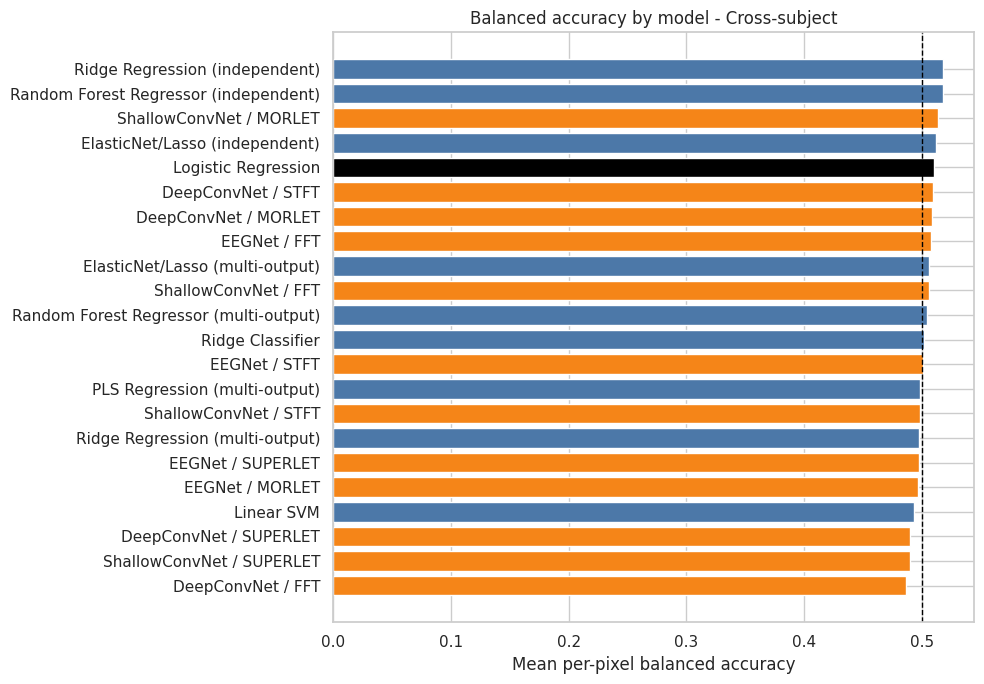

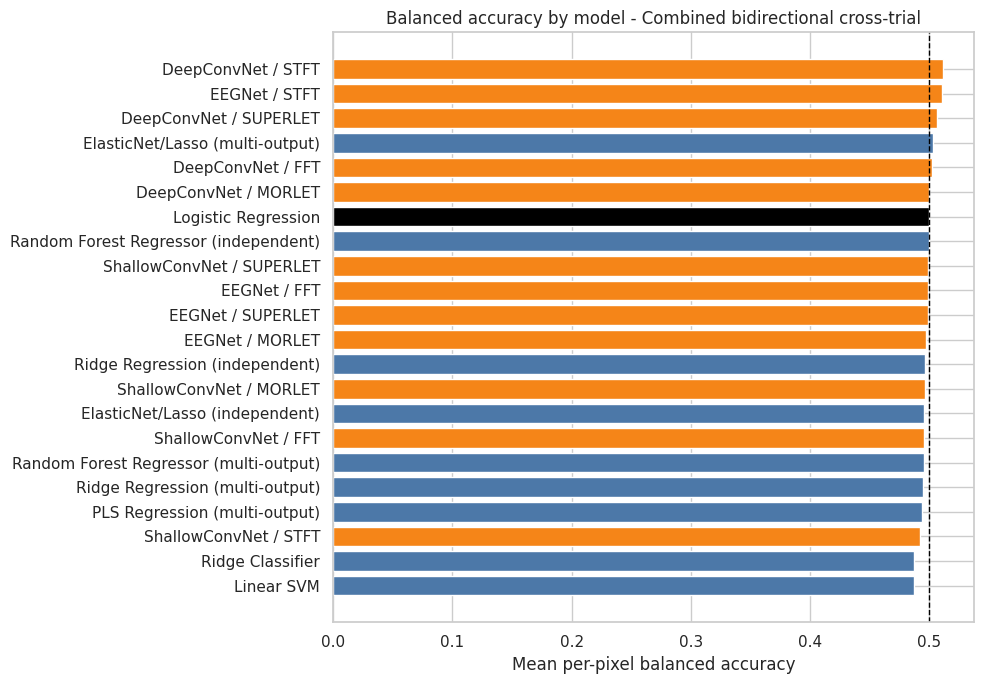

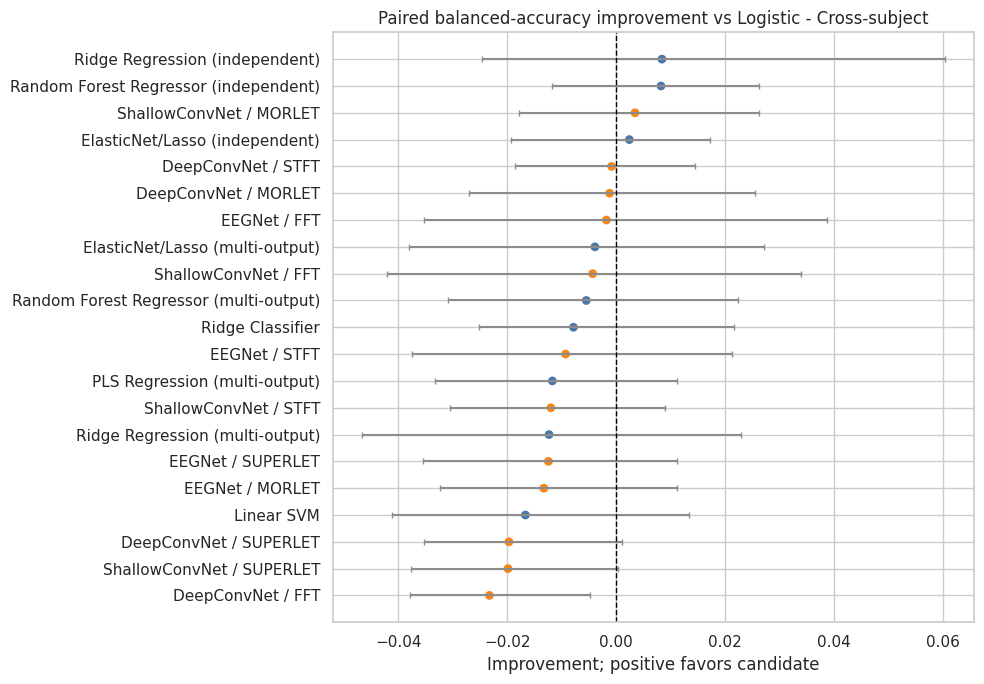

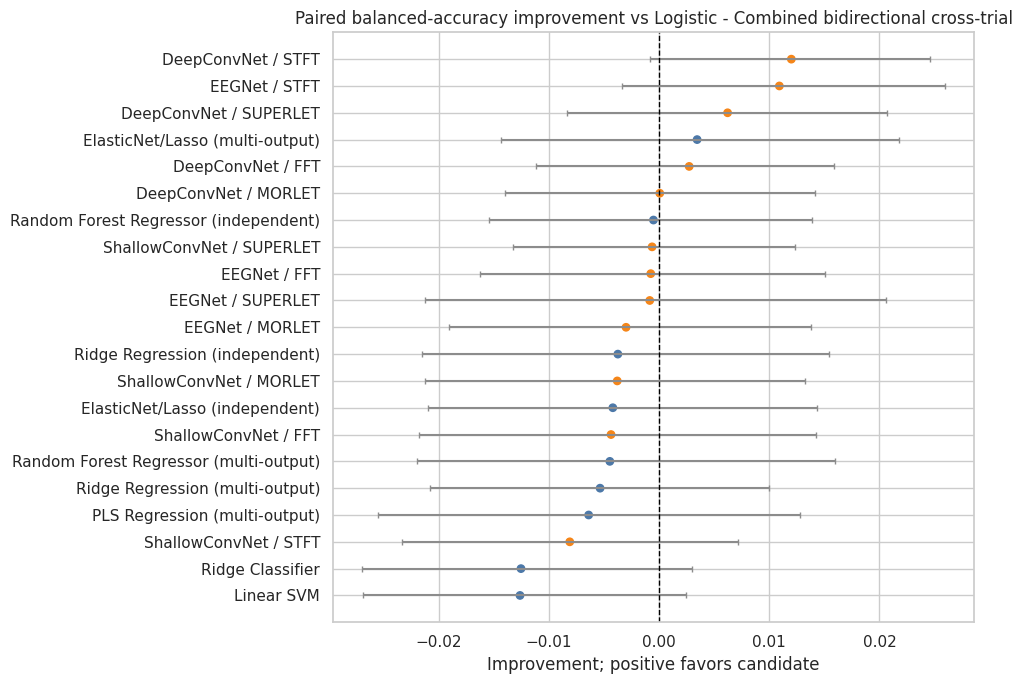

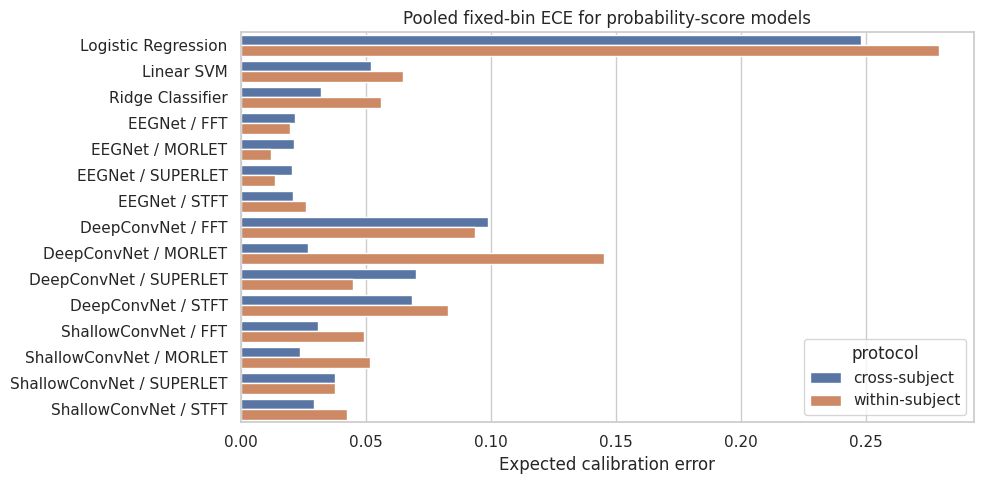

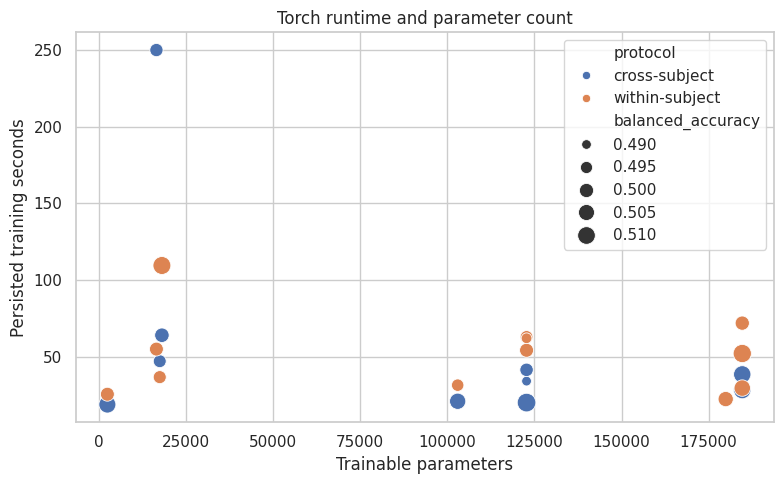

In [9]:
plot_df = comparison_df.copy()
for protocol in DIRECTION_ORDER:
    protocol_df = plot_df[plot_df["protocol"] == protocol].sort_values("balanced_accuracy")
    fig, ax = plt.subplots(figsize=(10, 7))
    colors = protocol_df["family"].map({"Reference": "black", "Classical": "#4C78A8", "Torch": "#F58518"})
    ax.barh(protocol_df["model"], protocol_df["balanced_accuracy"], color=colors)
    ax.axvline(0.5, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"Balanced accuracy by model - {PROTOCOL_LABELS[protocol]}")
    ax.set_xlabel("Mean per-pixel balanced accuracy")
    ax.set_ylabel("")
    fig.tight_layout()
    plt.show()

for protocol in DIRECTION_ORDER:
    protocol_df = ba_contrasts[ba_contrasts["protocol"] == protocol].sort_values("improvement")
    fig, ax = plt.subplots(figsize=(10, 7))
    colors = protocol_df["family"].map({"Classical": "#4C78A8", "Torch": "#F58518"})
    xerr = np.vstack(
        [
            protocol_df["improvement"] - protocol_df["pointwise_low"],
            protocol_df["pointwise_high"] - protocol_df["improvement"],
        ]
    )
    ax.errorbar(protocol_df["improvement"], protocol_df["model"], xerr=xerr, fmt="none", ecolor="0.55", capsize=2)
    ax.scatter(protocol_df["improvement"], protocol_df["model"], c=colors, s=28)
    ax.axvline(0.0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"Paired balanced-accuracy improvement vs Logistic - {PROTOCOL_LABELS[protocol]}")
    ax.set_xlabel("Improvement; positive favors candidate")
    ax.set_ylabel("")
    fig.tight_layout()
    plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=calibration_df, x="ece", y="model", hue="protocol", ax=ax)
ax.set_title("Pooled fixed-bin ECE for probability-score models")
ax.set_xlabel("Expected calibration error")
ax.set_ylabel("")
fig.tight_layout()
plt.show()

torch_runtime = runtime_df[runtime_df["family"] == "Torch"].merge(
    comparison_df[["protocol", "model_id", "balanced_accuracy"]],
    on=["protocol", "model_id"],
    how="left",
)
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=torch_runtime,
    x="parameter_count",
    y="training_seconds",
    hue="protocol",
    size="balanced_accuracy",
    sizes=(30, 180),
    ax=ax,
)
ax.set_title("Torch runtime and parameter count")
ax.set_xlabel("Trainable parameters")
ax.set_ylabel("Persisted training seconds")
fig.tight_layout()
plt.show()


## Takeaways

The strongest descriptive cross-subject values still come from classical regressors, while the strongest descriptive combined cross-trial values come from Torch STFT variants. Those rankings are small, protocol-specific, and do not survive the planned Holm-adjusted paired bootstrap screen against Logistic Regression.

The dominant scientific result remains conservative: the established random-imagery reconstruction task is near chance for the current EEG feature and spectral model families. The notebook therefore supports reproducible comparison and thesis reporting, not a claim that any model reliably decodes the random pixel imagery target.

In [10]:
cross_subject_leader = comparison_df[comparison_df["protocol"] == "cross-subject"].sort_values("balanced_accuracy", ascending=False).iloc[0]
within_subject_leader = comparison_df[comparison_df["protocol"] == "within-subject"].sort_values("balanced_accuracy", ascending=False).iloc[0]
print(
    "SUMMARY:",
    f"cross_subject_leader={cross_subject_leader['model_id']}:{cross_subject_leader['balanced_accuracy']:.6f}",
    f"within_subject_leader={within_subject_leader['model_id']}:{within_subject_leader['balanced_accuracy']:.6f}",
    f"min_holm_p={ba_contrasts['holm_p'].min():.6f}",
)
print("TORCH_CLASSICAL_COMPARISON_VERIFIED")


SUMMARY: cross_subject_leader=ridge-regression-independent:0.518382 within_subject_leader=deep-convnet-stft-multilabel:0.512011 min_holm_p=0.273000
TORCH_CLASSICAL_COMPARISON_VERIFIED
